In [8]:

import os
import gc
import io
import xarray as xr
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo


In [9]:

input_dir   = '/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/arctic_25km/TS_currents_lstm'
input_files = input_dir + '/TS_currents_lstm_*.nc'

output_dir_base = '/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/arctic_25km/plots'
means_dir_base  = '/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/arctic_25km/computed_means'

# Subdirs for plots — single-date/specific-date stay separate; mean dirs are
# shared with JN_plot_reconst_maps so ADH/vel PNGs land alongside TS PNGs.
out_single_date    = os.path.join(output_dir_base, 'single_date_adh_vel')
out_specific_dates = os.path.join(output_dir_base, 'specific_dates_midmonth')
out_seasonal       = os.path.join(output_dir_base, 'seasonal_means')
out_yearly         = os.path.join(output_dir_base, 'yearly_means')
out_grand          = os.path.join(output_dir_base, 'means')

# NC mean dirs: shared with JN_plot_reconst_maps (one unified computed_means tree)
nc_seasonal = os.path.join(means_dir_base, 'seasonal_means')
nc_yearly   = os.path.join(means_dir_base, 'yearly_means')
nc_grand    = os.path.join(means_dir_base, 'means')

for _d in (output_dir_base, out_specific_dates,
           out_seasonal, out_yearly, out_grand,
           means_dir_base, nc_seasonal, nc_yearly, nc_grand):
    os.makedirs(_d, exist_ok=True)


In [10]:

import glob

# Build sorted file list (one file per date, named TS_currents_lstm_YYYYMMDD.nc)
_all_files  = sorted(glob.glob(input_files))
_file_dates = [os.path.basename(f).replace('TS_currents_lstm_', '').replace('.nc', '')
               for f in _all_files]          # e.g. ['20110104', '20110107', ...]
_date_to_file = dict(zip(_file_dates, _all_files))

# Open a single reference file for coordinates, variable attrs and global attrs
_ds_ref = xr.open_dataset(_all_files[0], decode_times=False)

print(f'Found {len(_all_files)} files:  {_file_dates[0]}  ..  {_file_dates[-1]}')
print('Reference dataset:')
_ds_ref


Found 1395 files:  20110104  ..  20211228
Reference dataset:


<xarray.Dataset> Size: 836MB
Dimensions:            (time: 1, depth: 102, y_ease: 280, x_ease: 280)
Coordinates:
  * time               (time) float64 8B 2.228e+04
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * y_ease             (y_ease) float64 2kB -3.488e+06 -3.462e+06 ... 3.488e+06
  * x_ease             (x_ease) float64 2kB -3.488e+06 -3.462e+06 ... 3.488e+06
Data variables: (12/22)
    T_anom_pred        (time, depth, y_ease, x_ease) float64 64MB ...
    S_anom_pred        (time, depth, y_ease, x_ease) float64 64MB ...
    T_anom_std         (time, depth, y_ease, x_ease) float64 64MB ...
    S_anom_std         (time, depth, y_ease, x_ease) float64 64MB ...
    T_recon            (time, depth, y_ease, x_ease) float64 64MB ...
    S_recon            (time, depth, y_ease, x_ease) float64 64MB ...
    ...                 ...
    DOY                (time) int64 8B ...
    ocean_mask         (y_ease, x_ease) uint8 78kB ...
    elevation          (y_ease, x_ease) float64 627kB ...
    latitude           (y_ease, x_ease) float64 627kB ...
    longitude          (y_ease, x_ease) float64 627kB ...
    ease_grid_mapping  int64 8B ...
Attributes: (12/25)
    title:                       Arctic 4-D ocean reconstruction (ease_25km, ...
    summary:                     Arctic 4-D ocean reconstruction (ease_25km, ...
    Conventions:                 CF-1.8, ACDD-1.3
    source:                      LSTM with Monte-Carlo Dropout, trained on Ar...
    history:                     2026-05-12T13:45:37Z: file created
    creation_date:               2026-05-12T13:45:37Z
    ...                          ...
    model_path:                  /home/nicolas/SACO/FRESH-CARE/Codes/WP2/buon...
    glorys_mode:                 daily
    n_mc_samples:                500
    satellite_time_window_days:  16
    reconstruction_date:         2011-01-04
    geospatial_lat_min:          60.0

In [11]:

# ADH scalar plot configuration
adh_config = {
    'colormap': cmo.cm.tarn_r,
    'vmin': -0.7,
    'vmax':  0.7,
    'units': 'm',
}

# Geostrophic velocity plot configuration
vel_config = {
    'spd_vmax':        0.18,   # speed colorbar ceiling (m/s)
    'arrow_stride':    8,     # subsample every N grid points for quiver arrows
    'arrow_ref_speed': 0.2,   # m/s that maps to arrow_length inches
    'arrow_length':    0.33,    # inches for the reference arrow
    'arrow_width':     0.0038,
    'arrow_headwidth': 4,
    'arrow_headlength': 5,
    'head_axislength': 2,
    'units': 'm/s',
}

# Depths shown in every 4-panel composite (meters)
plotting_depths = [0, 30, 100, 800]

# Single date to preview (YYYY-MM-DD). Set to None to use the first time step.
single_date = '2015-08-16'


PLOT JUST ONE DATE FOR A START

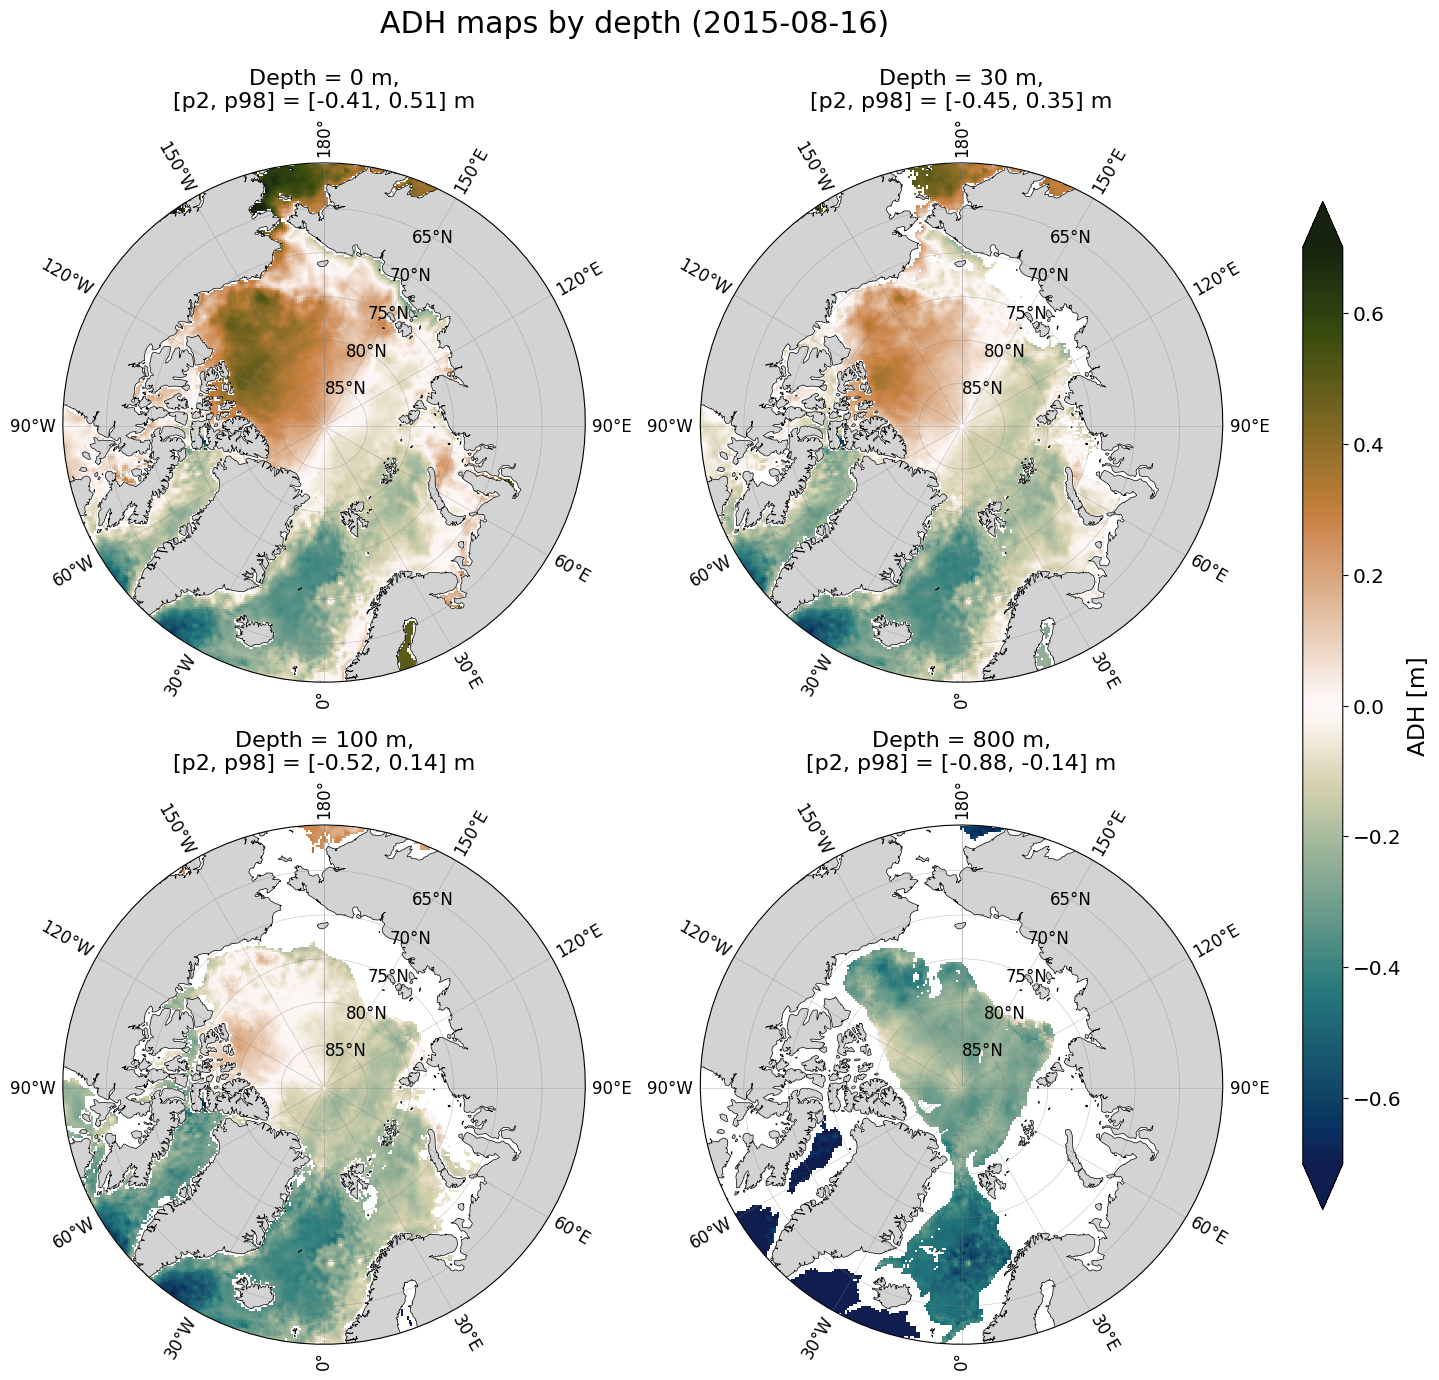

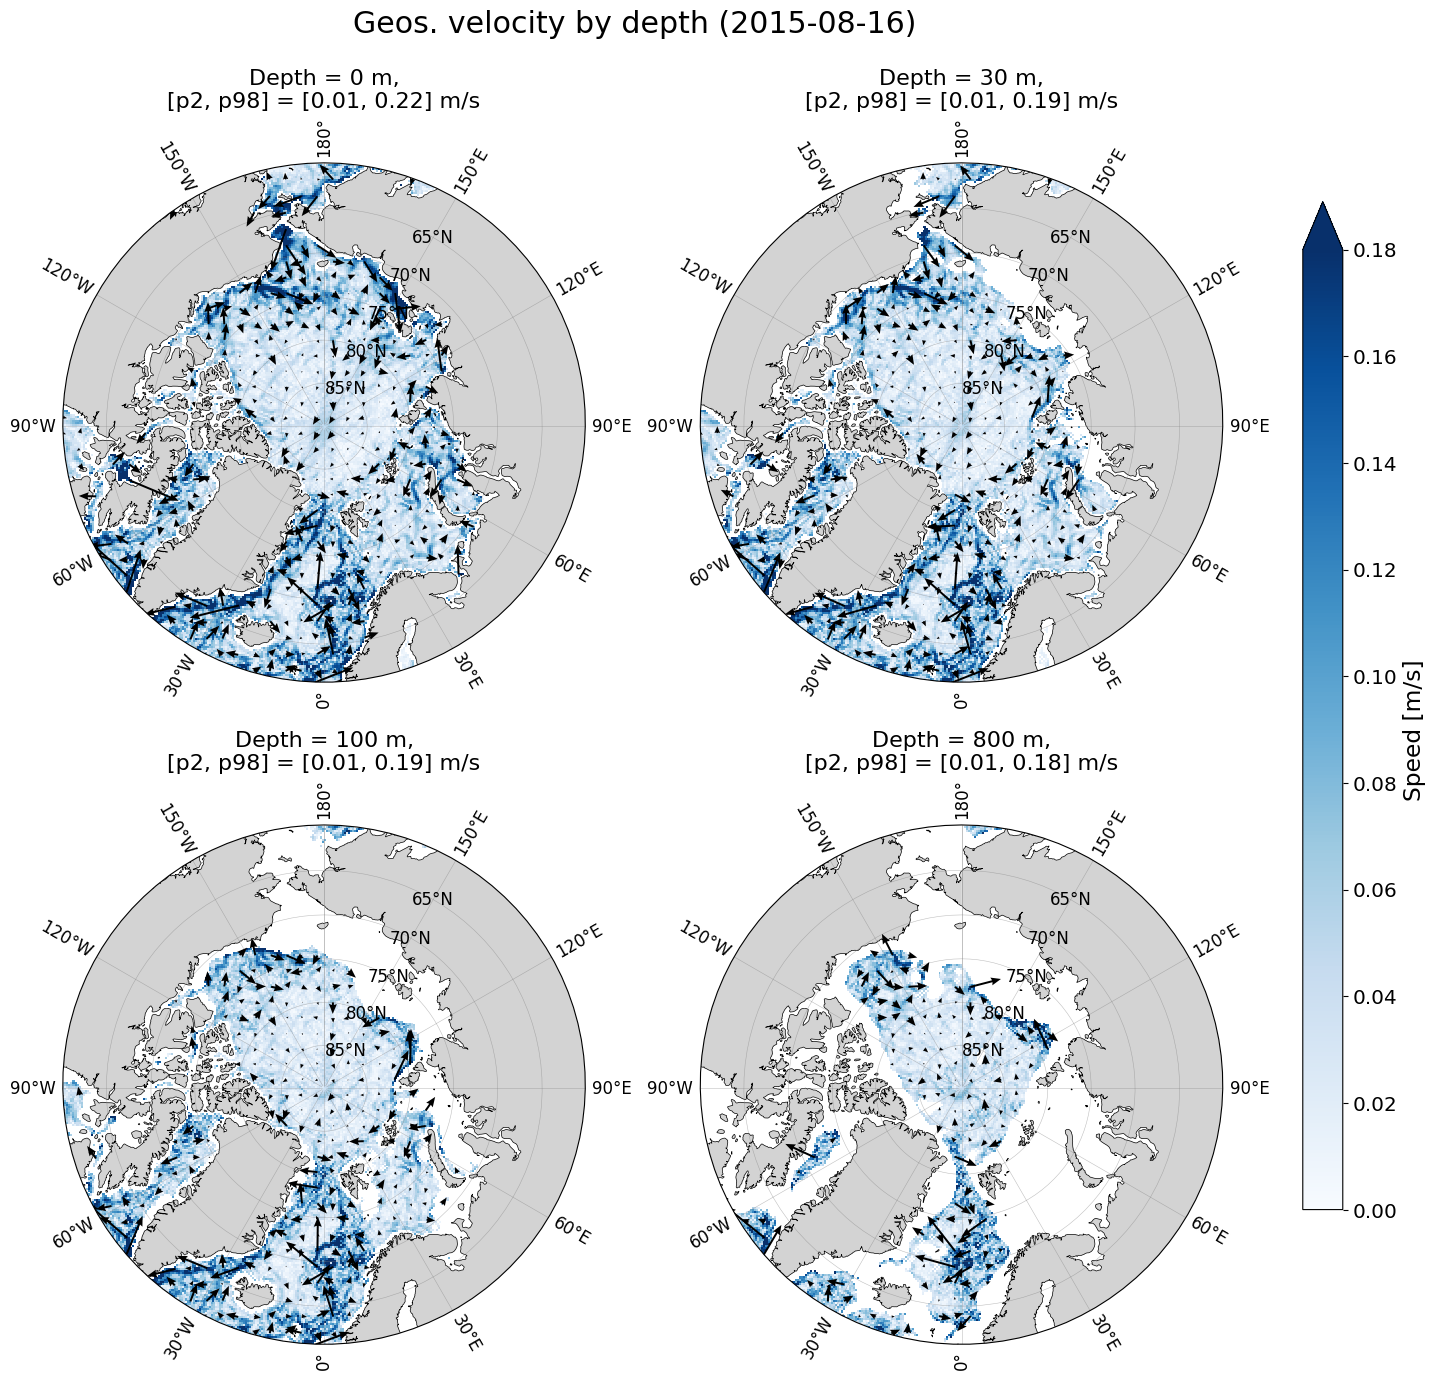

In [12]:

# Single-date preview: ADH and geostrophic currents, displayed inline (not saved).

_ease_p = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)

# EASE coords (positions for both pcolormesh and quiver)
_xe_p = _ds_ref['x_ease'].values
_ye_p = _ds_ref['y_ease'].values
if _xe_p.ndim == 1 and _ye_p.ndim == 1:
    _xe_p, _ye_p = np.meshgrid(_xe_p, _ye_p)

# Pick the requested date from the file list
_sel_date_str = single_date.replace('-', '') if single_date else _file_dates[0]
if _sel_date_str not in _date_to_file:
    raise ValueError(
        f"single_date={single_date!r} not in file list "
        f"(range: {_file_dates[0]} .. {_file_dates[-1]})"
    )
_ts_p = f'{_sel_date_str[:4]}-{_sel_date_str[4:6]}-{_sel_date_str[6:]}'

_dv_p    = _ds_ref['depth'].values
_di_p    = sorted({int(np.abs(_dv_p - d).argmin()) for d in plotting_depths})
_dvals_p = _dv_p[_di_p]


def _decorate_ax_p(ax):
    """Shared styling for a NorthPolarStereo panel (in-place). Title set separately."""
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    gl.xlocator = plt.MultipleLocator(30)
    gl.ylocator = plt.MultipleLocator(5)
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    th = np.linspace(0, 2 * np.pi, 100)
    vv = np.vstack([np.sin(th), np.cos(th)]).T
    ax.set_boundary(mpath.Path(vv * 0.5 + [0.5, 0.5]), transform=ax.transAxes)


def _show_composite_p(fig, cmap, vmin, vmax, cbar_label, title, extend='both'):
    """Finalize and display a composite figure (no PNG round-trip)."""
    fig.suptitle(f'{title}      ', fontsize=21.6, y=0.97)
    fig.subplots_adjust(top=0.90, right=0.85, hspace=0.10, wspace=0.22)
    sm = _cm.ScalarMappable(cmap=cmap, norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=fig.add_axes([0.90, 0.22, 0.025, 0.63]), extend=extend)
    cbar.set_label(cbar_label, fontsize=16.8)
    cbar.ax.tick_params(labelsize=14.4)
    plt.show()
    plt.close(fig)


# Open only the single file for this date
with xr.open_dataset(_date_to_file[_sel_date_str], decode_times=True) as _ds_day_p:
    # ---- ADH ----
    _adh_p = _ds_day_p['ADH'].isel(time=0, depth=_di_p).values
    _fig_p, _axes_p = plt.subplots(2, 2, figsize=(16, 16),
                                    subplot_kw={'projection': ccrs.NorthPolarStereo()})
    for _ax_p, k, dval in zip(_axes_p.flatten(), range(len(_dvals_p)), _dvals_p):
        _decorate_ax_p(_ax_p)
        _ax_p.pcolormesh(_xe_p, _ye_p, _adh_p[k], cmap=adh_config['colormap'],
                         transform=_ease_p, vmin=adh_config['vmin'],
                         vmax=adh_config['vmax'], shading='auto')
        p02 = np.nanpercentile(_adh_p[k], 2)
        p98 = np.nanpercentile(_adh_p[k], 98)
        u = f" {adh_config['units']}"
        _ax_p.set_title(f'Depth = {dval:.0f} m,\n[p2, p98] = [{p02:.2f}, {p98:.2f}]{u}',
                        fontsize=16)
    del _adh_p; gc.collect()
    _show_composite_p(_fig_p, adh_config['colormap'],
                      adh_config['vmin'], adh_config['vmax'],
                      f"ADH [{adh_config['units']}]",
                      f'ADH maps by depth ({_ts_p})')

    # ---- Geostrophic velocity (EASE-grid components, no rotation needed) ----
    _vx_p  = _ds_day_p['vel_gos_x'].isel(time=0, depth=_di_p).values
    _vy_p  = _ds_day_p['vel_gos_y'].isel(time=0, depth=_di_p).values
    _spd_p = np.hypot(_vx_p, _vy_p)
    _ss_p  = slice(None, None, vel_config['arrow_stride'])
    _xq_p  = _xe_p[_ss_p, _ss_p]
    _yq_p  = _ye_p[_ss_p, _ss_p]
    _qsc_p = vel_config['arrow_ref_speed'] / vel_config['arrow_length']

    _fig_p, _axes_p = plt.subplots(2, 2, figsize=(16, 16),
                                    subplot_kw={'projection': ccrs.NorthPolarStereo()})
    for _ax_p, k, dval in zip(_axes_p.flatten(), range(len(_dvals_p)), _dvals_p):
        _decorate_ax_p(_ax_p)
        _ax_p.pcolormesh(_xe_p, _ye_p, _spd_p[k], cmap='Blues',
                         transform=_ease_p, vmin=0, vmax=vel_config['spd_vmax'],
                         shading='auto')
        _ax_p.quiver(_xq_p, _yq_p,
                     _vx_p[k][_ss_p, _ss_p], _vy_p[k][_ss_p, _ss_p],
                     transform=_ease_p,
                     scale=_qsc_p, scale_units='inches',
                     width=vel_config['arrow_width'],
                     headwidth=vel_config['arrow_headwidth'],
                     headlength=vel_config['arrow_headlength'],
                     #headaxislength=vel_config['head_axislength'],
                     minlength=0,
                     color='black', zorder=2)
        p02 = np.nanpercentile(_spd_p[k], 2)
        p98 = np.nanpercentile(_spd_p[k], 98)
        u = f" {vel_config['units']}"
        _ax_p.set_title(f'Depth = {dval:.0f} m,\n[p2, p98] = [{p02:.2f}, {p98:.2f}]{u}',
                        fontsize=16)
    del _vx_p, _vy_p, _spd_p; gc.collect()
    _show_composite_p(_fig_p, 'Blues', 0, vel_config['spd_vmax'],
                      f"Speed [{vel_config['units']}]",
                      f'Geos. velocity by depth ({_ts_p})', extend='max')


SHARED CONFIG + HELPERS FOR BATCH PLOTS (specific dates, seasonal, yearly, grand mean)

In [14]:

# Shared config & helpers for every batch-plotting cell below.
import datetime, gc
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

# --- year range (inclusive) used by every batch cell ---
batch_year_start = 2011
batch_year_end   = 2021

# EASE coords (2D meshgrid) for both pcolormesh and quiver
_x_e = _ds_ref['x_ease'].values
_y_e = _ds_ref['y_ease'].values
if _x_e.ndim == 1 and _y_e.ndim == 1:
    _x_e, _y_e = np.meshgrid(_x_e, _y_e)

ease_crs = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)

# Time axis derived from file names
_years_all  = np.array([int(d[:4]) for d in _file_dates])
_months_all = np.array([int(d[4:6]) for d in _file_dates])

_in_range = (_years_all >= batch_year_start) & (_years_all <= batch_year_end)
print(f'Times in [{batch_year_start},{batch_year_end}]: '
      f'{int(_in_range.sum())} / {len(_file_dates)}')

_depth_values = _ds_ref['depth'].values

_depth_idx_sel = sorted({int(np.abs(_depth_values - d).argmin())
                         for d in plotting_depths})
_depth_vals_sel = _depth_values[_depth_idx_sel]
print(f'Reading only depth indices {_depth_idx_sel} '
      f'(depths {_depth_vals_sel.tolist()} m)')


# ── helpers: NC mean subdirs ──────────────────────────────────────────────────

def _nc_var_dir(nc_base, var):
    """Return (and create) the per-variable subdir under a computed_means base."""
    d = os.path.join(nc_base, var)
    os.makedirs(d, exist_ok=True)
    return d


# ── helpers: save / load mean NC ─────────────────────────────────────────────

def _save_mean_nc(mean_arr, var, depth_indices, out_path, mean_label):
    """Save a computed mean array as a CF-compliant NetCDF file."""
    depth_vals = _depth_values[depth_indices]
    now_str = datetime.datetime.now(datetime.UTC).strftime('%Y-%m-%dT%H:%M:%SZ')
    ds_out = xr.Dataset(
        {
            var: xr.DataArray(
                mean_arr,
                dims=['depth', 'y_ease', 'x_ease'],
                attrs={**dict(_ds_ref[var].attrs), 'cell_methods': 'time: mean'},
            )
        },
        coords={
            'depth':  ('depth',  depth_vals,               dict(_ds_ref['depth'].attrs)),
            'y_ease': ('y_ease', _ds_ref['y_ease'].values, dict(_ds_ref['y_ease'].attrs)),
            'x_ease': ('x_ease', _ds_ref['x_ease'].values, dict(_ds_ref['x_ease'].attrs)),
        },
        attrs={
            **{k: v for k, v in _ds_ref.attrs.items()
               if k not in ('history', 'creation_date', 'reconstruction_date')},
            'mean_type':     mean_label,
            'history':       f'{now_str}: mean computed from daily reconstruction files',
            'creation_date': now_str,
        }
    )
    ds_out.to_netcdf(out_path)
    ds_out.close()
    print(f'    Saved NC: {os.path.basename(out_path)}')


def _load_mean_nc(nc_path, var):
    """Load a mean array from a saved NC file. Returns ndarray (depth, y, x)."""
    with xr.open_dataset(nc_path) as f:
        arr = f[var].values.copy()
    return arr


# ── helper: decorate a cartopy axes in place ──────────────────────────────────

def _decorate_ax(ax):
    """Shared cartopy styling. Title is set separately per panel."""
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    gl.xlocator = plt.MultipleLocator(30)
    gl.ylocator = plt.MultipleLocator(5)
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    th = np.linspace(0, 2 * np.pi, 100)
    vv = np.vstack([np.sin(th), np.cos(th)]).T
    ax.set_boundary(mpath.Path(vv * 0.5 + [0.5, 0.5]), transform=ax.transAxes)


def _add_colorbar(fig, cmap, vmin, vmax, cbar_label, extend='both'):
    sm = _cm.ScalarMappable(cmap=cmap, norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
    cbar = fig.colorbar(sm, cax=cbar_ax, extend=extend)
    cbar.set_label(cbar_label, fontsize=16.8)
    cbar.ax.tick_params(labelsize=14.4)


# ── per-variable 4-panel plot functions ──────────────────────────────────────

def _plot_4panel_adh(data_dyx, depth_values, depths_m, out_path, title_extra=''):
    fig, axes = plt.subplots(2, 2, figsize=(16, 16),
                             subplot_kw={'projection': ccrs.NorthPolarStereo()})
    u = f" {adh_config['units']}"
    for ax, depth_target in zip(axes.flatten(), depths_m):
        depth_idx = int(np.abs(depth_values - depth_target).argmin())
        depth_used = float(depth_values[depth_idx])
        data = data_dyx[depth_idx]
        _decorate_ax(ax)
        ax.pcolormesh(_x_e, _y_e, data,
                      cmap=adh_config['colormap'], transform=ease_crs,
                      vmin=adh_config['vmin'], vmax=adh_config['vmax'],
                      shading='auto')
        p02 = np.nanpercentile(data, 2)
        p98 = np.nanpercentile(data, 98)
        ax.set_title(f'Depth = {depth_used:.0f} m,\n[p2, p98] = [{p02:.2f}, {p98:.2f}]{u}',
                     fontsize=16)
    fig.suptitle(f'ADH maps by depth ({title_extra})      ',
                 fontsize=21.6, y=0.97)
    fig.subplots_adjust(top=0.90, right=0.85, hspace=0.10, wspace=0.22)
    _add_colorbar(fig, adh_config['colormap'],
                  adh_config['vmin'], adh_config['vmax'],
                  f"ADH [{adh_config['units']}]")
    fig.savefig(out_path, dpi=350, bbox_inches='tight')
    plt.close(fig)
    gc.collect()


def _plot_4panel_vel(vx_dyx, vy_dyx, depth_values, depths_m, out_path, title_extra=''):
    """Plot speed (pcolormesh) + velocity arrows (quiver) using EASE-grid components.

    vx_dyx / vy_dyx are the grid-aligned x/y components (vel_gos_x, vel_gos_y).
    Quiver positions and transform both use ease_crs so no vector rotation is needed.
    """
    spd_dyx = np.hypot(vx_dyx, vy_dyx)
    s_step  = slice(None, None, vel_config['arrow_stride'])
    xq      = _x_e[s_step, s_step]
    yq      = _y_e[s_step, s_step]
    qscale  = vel_config['arrow_ref_speed'] / vel_config['arrow_length']

    fig, axes = plt.subplots(2, 2, figsize=(16, 16),
                             subplot_kw={'projection': ccrs.NorthPolarStereo()})
    u = f" {vel_config['units']}"
    for ax, depth_target in zip(axes.flatten(), depths_m):
        depth_idx = int(np.abs(depth_values - depth_target).argmin())
        depth_used = float(depth_values[depth_idx])
        spd = spd_dyx[depth_idx]
        _decorate_ax(ax)
        ax.pcolormesh(_x_e, _y_e, spd,
                      cmap='Blues', transform=ease_crs,
                      vmin=0, vmax=vel_config['spd_vmax'],
                      shading='auto')
        ax.quiver(xq, yq,
                  vx_dyx[depth_idx][s_step, s_step],
                  vy_dyx[depth_idx][s_step, s_step],
                  transform=ease_crs,
                  scale=qscale, scale_units='inches',
                  width=vel_config['arrow_width'],
                  headwidth=vel_config['arrow_headwidth'],
                  headlength=vel_config['arrow_headlength'],
                  color='black', zorder=2)
        p02 = np.nanpercentile(spd, 2)
        p98 = np.nanpercentile(spd, 98)
        ax.set_title(f'Depth = {depth_used:.0f} m,\n[p2, p98] = [{p02:.2f}, {p98:.2f}]{u}',
                     fontsize=16)
    fig.suptitle(f'Geos. velocity by depth ({title_extra})      ',
                 fontsize=21.6, y=0.97)
    fig.subplots_adjust(top=0.90, right=0.85, hspace=0.10, wspace=0.22)
    _add_colorbar(fig, 'Blues', 0, vel_config['spd_vmax'],
                  f"Speed [{vel_config['units']}]", extend='max')
    fig.savefig(out_path, dpi=350, bbox_inches='tight')
    plt.close(fig)
    gc.collect()


# ── RAM-safe incremental mean (opens one file at a time) ─────────────────────

def incremental_mean(date_strings, vars_list, label='', depth_indices=None):
    """NaN-aware mean over a list of daily file dates.

    Opens each reconstruction file individually so the full multi-year
    dataset never has to fit in RAM.
    """
    n = len(date_strings)
    if n == 0:
        raise ValueError(f'No dates provided for label {label!r}')
    sums   = {v: None for v in vars_list}
    counts = {v: None for v in vars_list}
    for k, date_str in enumerate(date_strings):
        fpath = _date_to_file[date_str]
        with xr.open_dataset(fpath, decode_times=True) as f:
            for v in vars_list:
                if depth_indices is not None:
                    arr = f[v].isel(time=0, depth=depth_indices).values.astype(np.float64)
                else:
                    arr = f[v].isel(time=0).values.astype(np.float64)
                mask = np.isfinite(arr)
                if sums[v] is None:
                    sums[v]   = np.where(mask, arr, 0.0)
                    counts[v] = mask.astype(np.int64)
                else:
                    sums[v]   += np.where(mask, arr, 0.0)
                    counts[v] += mask
                del arr, mask
        if (k + 1) % 50 == 0 or (k + 1) == n:
            print(f'  [{label}] {k + 1}/{n}')
    means = {}
    for v in vars_list:
        with np.errstate(invalid='ignore', divide='ignore'):
            m = sums[v] / counts[v]
        m[counts[v] == 0] = np.nan
        means[v] = m
    del sums, counts; gc.collect()
    return means


Times in [2011,2021]: 1395 / 1395
Reading only depth indices [0, 6, 20, 42] (depths [0.0, 30.0, 100.0, 800.0] m)


PLOT ADH AND VELOCITY ON SPECIFIC MID-MONTH DATES (Feb 16, May 16, Aug 16, Nov 16) ACROSS YEARS

In [ ]:

# Specific mid-month dates: Feb 16, May 16, Aug 16, Nov 16 for each year
# in [batch_year_start, batch_year_end]. One PNG per (variable, date).
# (Dataset has 3-day resolution, so day 15 is not present; using day 16.)

SKIP_EXISTING = False  # Set to False to overwrite existing files.

target_months_days = [(2, 16), (5, 16), (8, 16), (11, 16)]

out_adh_sd = os.path.join(out_specific_dates, 'ADH')
out_vel_sd = os.path.join(out_specific_dates, 'geos_vel')
os.makedirs(out_adh_sd, exist_ok=True)
os.makedirs(out_vel_sd, exist_ok=True)

# Build the list of datestrings for dates that exist in the file list
selected, missing = [], []
for yr in range(batch_year_start, batch_year_end + 1):
    for mo, dy in target_months_days:
        tag = f'{yr:04d}{mo:02d}{dy:02d}'
        if tag in _date_to_file:
            selected.append(tag)
        else:
            missing.append(f'{yr:04d}-{mo:02d}-{dy:02d}')

print(f'Selected {len(selected)} dates; missing {len(missing)}')
if missing:
    print('  missing:', missing)
print(f'Reading only depth indices {_depth_idx_sel} '
      f'(depths {_depth_vals_sel.tolist()} m)')

for tag in selected:
    date_iso = f'{tag[:4]}-{tag[4:6]}-{tag[6:]}'

    # --- ADH ---
    adh_png = os.path.join(out_adh_sd, f'{tag}_ADH_maps_4depths.png')
    if not (SKIP_EXISTING and os.path.exists(adh_png)):
        with xr.open_dataset(_date_to_file[tag], decode_times=True) as _f:
            data_adh = _f['ADH'].isel(time=0, depth=_depth_idx_sel).values
        _plot_4panel_adh(data_adh, _depth_vals_sel, plotting_depths,
                         adh_png, title_extra=date_iso)
        del data_adh; gc.collect()

    # --- Geostrophic velocity (EASE-grid components) ---
    vel_png = os.path.join(out_vel_sd, f'{tag}_geos_vel_maps_4depths.png')
    if not (SKIP_EXISTING and os.path.exists(vel_png)):
        with xr.open_dataset(_date_to_file[tag], decode_times=True) as _f:
            vx_data = _f['vel_gos_x'].isel(time=0, depth=_depth_idx_sel).values
            vy_data = _f['vel_gos_y'].isel(time=0, depth=_depth_idx_sel).values
        _plot_4panel_vel(vx_data, vy_data, _depth_vals_sel, plotting_depths,
                         vel_png, title_extra=date_iso)
        del vx_data, vy_data; gc.collect()

    print(f'  done {date_iso}')

print('Specific-date plotting finished.')


Selected 44 dates; missing 0
Reading only depth indices [0, 6, 20, 42] (depths [0.0, 30.0, 100.0, 800.0] m)
  done 2011-02-16
  done 2011-05-16
  done 2011-08-16
  done 2011-11-16
  done 2012-02-16
  done 2012-05-16
  done 2012-08-16
  done 2012-11-16
  done 2013-02-16
  done 2013-05-16
  done 2013-08-16
  done 2013-11-16
  done 2014-02-16
  done 2014-05-16
  done 2014-08-16
  done 2014-11-16
  done 2015-02-16
  done 2015-05-16
  done 2015-08-16
  done 2015-11-16
  done 2016-02-16
  done 2016-05-16
  done 2016-08-16
  done 2016-11-16
  done 2017-02-16
  done 2017-05-16
  done 2017-08-16
  done 2017-11-16
  done 2018-02-16
  done 2018-05-16
  done 2018-08-16
  done 2018-11-16
  done 2019-02-16
  done 2019-05-16
  done 2019-08-16
  done 2019-11-16
  done 2020-02-16
  done 2020-05-16
  done 2020-08-16
  done 2020-11-16
  done 2021-02-16
  done 2021-05-16
  done 2021-08-16
  done 2021-11-16
Specific-date plotting finished.


PLOT SEASONAL AVERAGES OVER A TIME RANGE

In [ ]:

# Seasonal means per year (DJF, MAM, JJA, SON).
# DJF year convention: Dec(Y-1) + Jan(Y) + Feb(Y)  →  labelled {Y}_DJF.
# Means are saved as NC files and re-used on subsequent runs.

USE_EXISTING_COMPUTATION = True  # Load pre-computed mean NC if it exists; False to recompute+overwrite.
SKIP_EXISTING            = False  # Skip PNG generation if the file already exists.

_MONTH_TO_SEASON = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    3:  'MAM', 4: 'MAM', 5: 'MAM',
    6:  'JJA', 7: 'JJA', 8: 'JJA',
    9:  'SON', 10: 'SON', 11: 'SON',
}

out_adh_s = os.path.join(out_seasonal, 'ADH')
out_vel_s = os.path.join(out_seasonal, 'geos_vel')
os.makedirs(out_adh_s, exist_ok=True)
os.makedirs(out_vel_s, exist_ok=True)

# Group file dates by (label_year, season).
# DJF: December of year Y contributes to label_year = Y+1.
# All other seasons: label_year = year of the file.
from collections import defaultdict
season_year_dates = defaultdict(list)  # key: (label_year, season)

for i, d in enumerate(_file_dates):
    if not _in_range[i]:
        continue
    yr  = _years_all[i]
    mo  = _months_all[i]
    sea = _MONTH_TO_SEASON[mo]
    label_year = yr + 1 if mo == 12 else yr
    # Exclude DJF labels that fall outside the requested year range
    if batch_year_start <= label_year <= batch_year_end:
        season_year_dates[(label_year, sea)].append(d)

for (yr, sea), dates in sorted(season_year_dates.items()):
    print(f'{yr}_{sea}: {len(dates)} time steps')

_MEAN_VARS = ['ADH', 'vel_gos_x', 'vel_gos_y']

for (label_year, season), dates in sorted(season_year_dates.items()):
    if not dates:
        continue

    pfx         = f'{label_year}_{season}'
    title_extra = f'{season} {label_year}'

    # ── Step 1: compute & save missing NC means ────────────────────────────
    vars_to_compute = []
    for var in _MEAN_VARS:
        nc_path = os.path.join(_nc_var_dir(nc_seasonal, var), f'{pfx}_{var}_mean.nc')
        if USE_EXISTING_COMPUTATION and os.path.exists(nc_path):
            print(f'  NC exists, skipping computation: {pfx} {var}')
        else:
            vars_to_compute.append(var)

    if vars_to_compute:
        print(f'Computing {pfx} mean ({len(dates)} steps, vars: {vars_to_compute})...')
        new_means = incremental_mean(dates, vars_to_compute, label=pfx,
                                     depth_indices=_depth_idx_sel)
        for var in vars_to_compute:
            nc_path = os.path.join(_nc_var_dir(nc_seasonal, var), f'{pfx}_{var}_mean.nc')
            _save_mean_nc(new_means[var], var, _depth_idx_sel, nc_path,
                          f'{season} mean {label_year}')
        del new_means; gc.collect()

    # ── Step 2: plot ADH ───────────────────────────────────────────────────
    adh_png = os.path.join(out_adh_s, f'{pfx}_ADH_maps_4depths.png')
    if not (SKIP_EXISTING and os.path.exists(adh_png)):
        nc_path = os.path.join(_nc_var_dir(nc_seasonal, 'ADH'), f'{pfx}_ADH_mean.nc')
        adh_arr = _load_mean_nc(nc_path, 'ADH')
        _plot_4panel_adh(adh_arr, _depth_vals_sel, plotting_depths,
                         adh_png, title_extra=title_extra)
        del adh_arr; gc.collect()
    else:
        print(f'  PNG exists, skipping: {pfx} ADH')

    # ── Step 3: plot velocity ──────────────────────────────────────────────
    vel_png = os.path.join(out_vel_s, f'{pfx}_geos_vel_maps_4depths.png')
    if not (SKIP_EXISTING and os.path.exists(vel_png)):
        vx_arr = _load_mean_nc(os.path.join(_nc_var_dir(nc_seasonal, 'vel_gos_x'),
                                             f'{pfx}_vel_gos_x_mean.nc'), 'vel_gos_x')
        vy_arr = _load_mean_nc(os.path.join(_nc_var_dir(nc_seasonal, 'vel_gos_y'),
                                             f'{pfx}_vel_gos_y_mean.nc'), 'vel_gos_y')
        _plot_4panel_vel(vx_arr, vy_arr, _depth_vals_sel, plotting_depths,
                         vel_png, title_extra=title_extra)
        del vx_arr, vy_arr; gc.collect()
    else:
        print(f'  PNG exists, skipping: {pfx} geos_vel')

    print(f'  {pfx} done.')

print('Seasonal batch plotting finished.')


2011_DJF: 20 time steps
2011_JJA: 32 time steps
2011_MAM: 32 time steps
2011_SON: 31 time steps
2012_DJF: 32 time steps
2012_JJA: 32 time steps
2012_MAM: 32 time steps
2012_SON: 31 time steps
2013_DJF: 32 time steps
2013_JJA: 32 time steps
2013_MAM: 32 time steps
2013_SON: 31 time steps
2014_DJF: 32 time steps
2014_JJA: 32 time steps
2014_MAM: 32 time steps
2014_SON: 31 time steps
2015_DJF: 32 time steps
2015_JJA: 32 time steps
2015_MAM: 32 time steps
2015_SON: 31 time steps
2016_DJF: 32 time steps
2016_JJA: 32 time steps
2016_MAM: 32 time steps
2016_SON: 31 time steps
2017_DJF: 32 time steps
2017_JJA: 32 time steps
2017_MAM: 32 time steps
2017_SON: 31 time steps
2018_DJF: 32 time steps
2018_JJA: 32 time steps
2018_MAM: 32 time steps
2018_SON: 31 time steps
2019_DJF: 32 time steps
2019_JJA: 32 time steps
2019_MAM: 32 time steps
2019_SON: 31 time steps
2020_DJF: 32 time steps
2020_JJA: 32 time steps
2020_MAM: 32 time steps
2020_SON: 31 time steps
2021_DJF: 32 time steps
2021_JJA: 32 tim

PLOT YEARLY AVERAGES

In [ ]:

# Yearly means across [batch_year_start, batch_year_end].
# Means are saved as NC files and re-used on subsequent runs.

USE_EXISTING_COMPUTATION = True  # Load pre-computed mean NC if it exists; False to recompute+overwrite.
SKIP_EXISTING            = False  # Skip PNG generation if the file already exists.

out_adh_y = os.path.join(out_yearly, 'ADH')
out_vel_y = os.path.join(out_yearly, 'geos_vel')
os.makedirs(out_adh_y, exist_ok=True)
os.makedirs(out_vel_y, exist_ok=True)

_MEAN_VARS = ['ADH', 'vel_gos_x', 'vel_gos_y']

for yr in range(batch_year_start, batch_year_end + 1):
    yr_dates = [d for d, y in zip(_file_dates, _years_all) if y == yr]
    if not yr_dates:
        print(f'Skipping {yr} (no data).'); continue

    # ── Step 1: compute & save missing NC means ────────────────────────────
    vars_to_compute = []
    for var in _MEAN_VARS:
        nc_path = os.path.join(_nc_var_dir(nc_yearly, var), f'{yr}_{var}_mean.nc')
        if USE_EXISTING_COMPUTATION and os.path.exists(nc_path):
            print(f'  NC exists, skipping computation: {yr} {var}')
        else:
            vars_to_compute.append(var)

    if vars_to_compute:
        print(f'Computing {yr} mean ({len(yr_dates)} steps, vars: {vars_to_compute})...')
        new_means = incremental_mean(yr_dates, vars_to_compute, label=str(yr),
                                     depth_indices=_depth_idx_sel)
        for var in vars_to_compute:
            nc_path = os.path.join(_nc_var_dir(nc_yearly, var), f'{yr}_{var}_mean.nc')
            _save_mean_nc(new_means[var], var, _depth_idx_sel, nc_path,
                          f'{yr} annual mean')
        del new_means; gc.collect()

    # ── Step 2: plot ADH ───────────────────────────────────────────────────
    adh_png = os.path.join(out_adh_y, f'{yr}_ADH_maps_4depths.png')
    if not (SKIP_EXISTING and os.path.exists(adh_png)):
        adh_arr = _load_mean_nc(
            os.path.join(_nc_var_dir(nc_yearly, 'ADH'), f'{yr}_ADH_mean.nc'), 'ADH')
        _plot_4panel_adh(adh_arr, _depth_vals_sel, plotting_depths,
                         adh_png, title_extra=f'{yr} mean')
        del adh_arr; gc.collect()
    else:
        print(f'  PNG exists, skipping: {yr} ADH')

    # ── Step 3: plot velocity ──────────────────────────────────────────────
    vel_png = os.path.join(out_vel_y, f'{yr}_geos_vel_maps_4depths.png')
    if not (SKIP_EXISTING and os.path.exists(vel_png)):
        vx_arr = _load_mean_nc(
            os.path.join(_nc_var_dir(nc_yearly, 'vel_gos_x'), f'{yr}_vel_gos_x_mean.nc'),
            'vel_gos_x')
        vy_arr = _load_mean_nc(
            os.path.join(_nc_var_dir(nc_yearly, 'vel_gos_y'), f'{yr}_vel_gos_y_mean.nc'),
            'vel_gos_y')
        _plot_4panel_vel(vx_arr, vy_arr, _depth_vals_sel, plotting_depths,
                         vel_png, title_extra=f'{yr} mean')
        del vx_arr, vy_arr; gc.collect()
    else:
        print(f'  PNG exists, skipping: {yr} geos_vel')

    print(f'  {yr} done.')

print('Yearly batch plotting finished.')


Computing 2011 mean (126 steps, vars: ['ADH', 'vel_gos_x', 'vel_gos_y'])...
  [2011] 50/126
  [2011] 100/126
  [2011] 126/126
    Saved NC: 2011_ADH_mean.nc
    Saved NC: 2011_vel_gos_x_mean.nc
    Saved NC: 2011_vel_gos_y_mean.nc
  2011 done.
Computing 2012 mean (127 steps, vars: ['ADH', 'vel_gos_x', 'vel_gos_y'])...
  [2012] 50/127
  [2012] 100/127
  [2012] 127/127
    Saved NC: 2012_ADH_mean.nc
    Saved NC: 2012_vel_gos_x_mean.nc
    Saved NC: 2012_vel_gos_y_mean.nc
  2012 done.
Computing 2013 mean (127 steps, vars: ['ADH', 'vel_gos_x', 'vel_gos_y'])...
  [2013] 50/127
  [2013] 100/127
  [2013] 127/127
    Saved NC: 2013_ADH_mean.nc
    Saved NC: 2013_vel_gos_x_mean.nc
    Saved NC: 2013_vel_gos_y_mean.nc
  2013 done.
Computing 2014 mean (127 steps, vars: ['ADH', 'vel_gos_x', 'vel_gos_y'])...
  [2014] 50/127
  [2014] 100/127
  [2014] 127/127
    Saved NC: 2014_ADH_mean.nc
    Saved NC: 2014_vel_gos_x_mean.nc
    Saved NC: 2014_vel_gos_y_mean.nc
  2014 done.
Computing 2015 mean (127

PLOT GRAND MEAN OVER THE FULL DATE RANGE

In [15]:

# Grand mean over all time steps in [batch_year_start, batch_year_end].
# Means are saved as NC files and re-used on subsequent runs.

USE_EXISTING_COMPUTATION = True  # Load pre-computed mean NC if it exists; False to recompute+overwrite.
SKIP_EXISTING            = False  # Skip PNG generation if the file already exists.

os.makedirs(nc_grand, exist_ok=True)
pfx = f'{batch_year_start}_{batch_year_end}'
title_extra = f'grand mean {batch_year_start}-{batch_year_end}'

_MEAN_VARS = ['ADH', 'vel_gos_x', 'vel_gos_y']
all_dates  = [d for d, r in zip(_file_dates, _in_range) if r]

# ── Step 1: compute & save missing NC means ────────────────────────────────
vars_to_compute = []
for var in _MEAN_VARS:
    nc_path = os.path.join(nc_grand, f'{pfx}_grandmean_{var}_mean.nc')
    if USE_EXISTING_COMPUTATION and os.path.exists(nc_path):
        print(f'  NC exists, skipping computation: grand mean {var}')
    else:
        vars_to_compute.append(var)

if vars_to_compute:
    print(f'Computing grand mean ({len(all_dates)} steps, vars: {vars_to_compute})...')
    new_means = incremental_mean(all_dates, vars_to_compute, label='grand',
                                 depth_indices=_depth_idx_sel)
    for var in vars_to_compute:
        nc_path = os.path.join(nc_grand, f'{pfx}_grandmean_{var}_mean.nc')
        _save_mean_nc(new_means[var], var, _depth_idx_sel, nc_path,
                      f'grand mean {batch_year_start}-{batch_year_end}')
    del new_means; gc.collect()

# ── Step 2: plot ADH ──────────────────────────────────────────────────────
adh_png = os.path.join(out_grand, f'{pfx}_grandmean_ADH_maps_4depths.png')
if not (SKIP_EXISTING and os.path.exists(adh_png)):
    adh_arr = _load_mean_nc(
        os.path.join(nc_grand, f'{pfx}_grandmean_ADH_mean.nc'), 'ADH')
    _plot_4panel_adh(adh_arr, _depth_vals_sel, plotting_depths,
                     adh_png, title_extra=title_extra)
    del adh_arr; gc.collect()
else:
    print('  PNG exists, skipping: grand mean ADH')

# ── Step 3: plot velocity ─────────────────────────────────────────────────
vel_png = os.path.join(out_grand, f'{pfx}_grandmean_geos_vel_maps_4depths.png')
if not (SKIP_EXISTING and os.path.exists(vel_png)):
    vx_arr = _load_mean_nc(
        os.path.join(nc_grand, f'{pfx}_grandmean_vel_gos_x_mean.nc'), 'vel_gos_x')
    vy_arr = _load_mean_nc(
        os.path.join(nc_grand, f'{pfx}_grandmean_vel_gos_y_mean.nc'), 'vel_gos_y')
    _plot_4panel_vel(vx_arr, vy_arr, _depth_vals_sel, plotting_depths,
                     vel_png, title_extra=title_extra)
    del vx_arr, vy_arr; gc.collect()
else:
    print('  PNG exists, skipping: grand mean geos_vel')

print('Grand-mean plotting finished.')


  NC exists, skipping computation: grand mean ADH
  NC exists, skipping computation: grand mean vel_gos_x
  NC exists, skipping computation: grand mean vel_gos_y
Grand-mean plotting finished.
